# Shor Period-Finding Benchmark — Tutorial

This notebook is being built up section by section as the benchmark implementation
is reviewed. Sections so far:

1. **Primitive polynomial generation** — the internals used to build the
   period-finding permutation.
2. **CNOT synthesis (Patel–Markov–Hayes)** — how each controlled power of the
   permutation is compiled into CNOTs; correctness check and CNOT-count
   comparison against Qiskit's implementation.

## Primitive polynomial generation (internals review)

The period-finding circuit is built around a maximum-cycle linear permutation of
the target register, represented as the companion matrix of a **primitive
polynomial over GF(2)**. Three private helpers in `frontier.shorbenchmark.shorbenchmark`
implement this:

- `mersenne_prime_factors(degree)` (in `_mersenne_factors.py`) — looks up the complete
  set of distinct prime factors of `2**degree - 1` from a precomputed table
  (generated offline via `scripts/generate_mersenne_factor_table.py`, currently
  covering degrees 1–200). This replaces factoring `2**degree - 1` at runtime,
  which is only feasible for very small degrees.
- `_is_primitive_polynomial(poly)` — tests whether a GF(2) polynomial (encoded as an
  int bitmask) is primitive, using the factorization above.
- `_primitive_polynomial_for_degree(degree, sample_id)` — finds a primitive
  polynomial of the requested degree via **seeded random search**: candidates are
  drawn from a `random.Random(f"{degree}:{sample_id}")` generator and tested with
  `_is_primitive_polynomial` until one passes. This is deterministic and
  reproducible per `(degree, sample_id)`, but does not preserve any particular
  ordering among primitive polynomials.

These are private (underscore-prefixed) implementation details, not part of the
public API — imported directly here for review purposes only.

In [1]:
from frontier.shorbenchmark.shorbenchmark import (
    _is_primitive_polynomial,
    _primitive_polynomial_for_degree,
    _poly_degree,
)
from frontier.shorbenchmark._mersenne_factors import mersenne_prime_factors

### The Mersenne factor lookup table

For a given degree `n`, `mersenne_prime_factors(n)` returns the distinct prime
factors of `2**n - 1`. Every entry in the table is a *complete* factorization
(no missing/unknown factors) — that completeness is what makes the primitivity
test below correct.

In [2]:
for degree in [1, 2, 3, 8, 17, 64, 127, 200]:
    factors = mersenne_prime_factors(degree)
    order = (1 << degree) - 1
    product_of_factors_divides_order = all(order % p == 0 for p in factors)
    print(f"degree={degree:3d}  order=2**{degree}-1  num_prime_factors={len(factors):3d}  "
          f"all_divide_order={product_of_factors_divides_order}")
    print(f"    factors: {factors}")

degree=  1  order=2**1-1  num_prime_factors=  0  all_divide_order=True
    factors: ()
degree=  2  order=2**2-1  num_prime_factors=  1  all_divide_order=True
    factors: (3,)
degree=  3  order=2**3-1  num_prime_factors=  1  all_divide_order=True
    factors: (7,)
degree=  8  order=2**8-1  num_prime_factors=  3  all_divide_order=True
    factors: (3, 5, 17)
degree= 17  order=2**17-1  num_prime_factors=  1  all_divide_order=True
    factors: (131071,)
degree= 64  order=2**64-1  num_prime_factors=  7  all_divide_order=True
    factors: (3, 5, 17, 257, 641, 65537, 6700417)
degree=127  order=2**127-1  num_prime_factors=  1  all_divide_order=True
    factors: (170141183460469231731687303715884105727,)
degree=200  order=2**200-1  num_prime_factors= 18  all_divide_order=True
    factors: (3, 5, 11, 17, 31, 41, 101, 251, 401, 601, 1801, 4051, 8101, 61681, 268501, 340801, 2787601, 3173389601)


In [3]:
# A degree outside the table's coverage raises a clear error instead of
# silently doing something incorrect.
try:
    mersenne_prime_factors(10000)
except KeyError as exc:
    print("KeyError as expected:", exc)

KeyError as expected: 'No precomputed factorization of 2**10000 - 1 is available. The table currently covers degrees up to 200. Extend it with scripts/generate_mersenne_factor_table.py.'


### Primitivity testing

`_is_primitive_polynomial` takes a polynomial encoded as an int (bit `i` is the
coefficient of `x**i`) and returns whether it's primitive over GF(2). A few
concrete, well-known examples below: `x**3 + x + 1` (0b1011) and
`x**4 + x + 1` (0b10011) are textbook primitive polynomials.

In [4]:
examples = {
    "x^3 + x + 1": 0b1011,
    "x^4 + x + 1": 0b10011,
    "x^3 + x^2 + 1": 0b1101,     # also primitive (degree 3 has two primitive polys)
    "x^4 + x^3 + x^2 + x + 1": 0b11111,  # irreducible but NOT primitive
}
for name, poly in examples.items():
    print(f"{name:30s} degree={_poly_degree(poly)}  primitive={_is_primitive_polynomial(poly)}")

x^3 + x + 1                    degree=3  primitive=True
x^4 + x + 1                    degree=4  primitive=True
x^3 + x^2 + 1                  degree=3  primitive=True
x^4 + x^3 + x^2 + x + 1        degree=4  primitive=False


### Generating a primitive polynomial by seeded random search

`_primitive_polynomial_for_degree(degree, sample_id)` should:
1. Return a genuinely primitive polynomial of the requested degree.
2. Be deterministic — the same `(degree, sample_id)` always gives the same result.
3. Be fast even at degrees where brute-force enumeration of all `2**(degree-1)`
   candidates would be completely infeasible (the previous implementation's problem).

In [5]:
import time

for degree in [3, 8, 20, 32, 64, 128, 200]:
    start = time.perf_counter()
    poly = _primitive_polynomial_for_degree(degree, sample_id=0)
    elapsed = time.perf_counter() - start
    assert _is_primitive_polynomial(poly)
    assert _poly_degree(poly) == degree
    print(f"degree={degree:4d}  time={elapsed:6.4f}s  poly={bin(poly)}")

degree=   3  time=0.0001s  poly=0b1101
degree=   8  time=0.0004s  poly=0b111110101
degree=  20  time=0.0014s  poly=0b110010001101000110111
degree=  32  time=0.0087s  poly=0b101010111111010101010011110100001
degree=  64  time=0.0959s  poly=0b10101111101111001111011000001101110101110000001000001011110010101


degree= 128  time=0.9917s  poly=0b100100011010010111010010010100100101001110110101101100001010010110010100110000011011011011110101101110010101000101111010000101001


degree= 200  time=3.5447s  poly=0b101001001100100101010000010100001111101000000111010111101000111011001010101010110010000000000110010000111111000101111000001100000101100101101101100110100000101010110001101000111001111111011100101010111


In [6]:
# Determinism: same (degree, sample_id) -> same polynomial.
for degree, sample_id in [(20, 0), (20, 1), (64, 3)]:
    first = _primitive_polynomial_for_degree(degree, sample_id)
    second = _primitive_polynomial_for_degree(degree, sample_id)
    print(f"degree={degree} sample_id={sample_id}  match={first == second}")

degree=20 sample_id=0  match=True
degree=20 sample_id=1  match=True


degree=64 sample_id=3  match=True


In [7]:
# Different sample_ids at the same degree generally give different polynomials.
polys = {sid: _primitive_polynomial_for_degree(20, sid) for sid in range(10)}
for sid, poly in polys.items():
    print(f"sample_id={sid}  poly={bin(poly)}")
print(f"distinct polynomials out of {len(polys)} sample_ids: {len(set(polys.values()))}")

sample_id=0  poly=0b110010001101000110111
sample_id=1  poly=0b101101000101101110111
sample_id=2  poly=0b101111010101001101011
sample_id=3  poly=0b100110010001101111111
sample_id=4  poly=0b101111010010010101001
sample_id=5  poly=0b110001101111000110001
sample_id=6  poly=0b100011111011001100111
sample_id=7  poly=0b110001110111010001001
sample_id=8  poly=0b110011000010000000011
sample_id=9  poly=0b110011000000101011111
distinct polynomials out of 10 sample_ids: 10


In [8]:
# A degree beyond the factor table's coverage propagates the same KeyError
# seen above, rather than silently returning something wrong.
try:
    _primitive_polynomial_for_degree(10000, sample_id=0)
except KeyError as exc:
    print("KeyError as expected:", exc)

KeyError as expected: 'No precomputed factorization of 2**10000 - 1 is available. The table currently covers degrees up to 200. Extend it with scripts/generate_mersenne_factor_table.py.'


## CNOT synthesis of the controlled permutation powers (Patel–Markov–Hayes)

The heart of each benchmark circuit is the sequence of controlled powers
`M**(2**k)` of the companion matrix, each compiled into CNOTs by
`_synthesize_linear_map`. A CNOT with control `c` and target `t` maps the bit
vector `v` of a computational basis state by `v[t] ^= v[c]` — exactly one
elementary row operation over GF(2) — so any invertible GF(2) matrix can be
synthesized by (reversed) Gaussian elimination.

`_pmh_cnot_schedule` implements the **Patel–Markov–Hayes (PMH)** algorithm
(quant-ph/0302002): before eliminating column by column, rows that are identical
*within a block of m columns* are cancelled against one representative row — one
CNOT each — so with block width m ≈ log₂(n) the CNOT count drops from O(n²)
(plain elimination) to the asymptotically optimal O(n² / log n). On top of the
paper's algorithm, `_pmh_cnot_schedule` tries every block width up to ~log₂(n)
and keeps the shortest schedule; synthesis costs O(n²) bit operations per
attempt, so this is essentially free.

Below: a correctness check (replaying the schedule must reproduce the matrix),
then a CNOT-count comparison against

- the package's **previous implementation** (plain Gauss–Jordan elimination, the baseline),
- **Qiskit's** `synth_cnot_count_full_pmh` at its default section size, and
- Qiskit's PMH with the section size **swept** and the best result kept
  (the same trick our scheduler applies internally).

*Qiskit is used for comparison only — installed ad hoc into this venv
(`pip install qiskit`), not a dependency of the package.*

In [9]:
import numpy as np

from frontier.shorbenchmark.shorbenchmark import (
    _companion_matrix_from_polynomial,
    _matrix_power_mod2,
    _pmh_cnot_schedule,
)


def apply_schedule(schedule, size):
    """Multiply out a CNOT schedule (in circuit order) as GF(2) row operations."""
    result = np.eye(size, dtype=np.uint8)
    for control, target in schedule:
        result[target, :] ^= result[control, :]
    return result


# Correctness: replaying the schedule must reproduce exactly the matrices the
# benchmark synthesizes — every controlled power M**(2**k) of the companion matrix.
for degree in [3, 8, 13, 20]:
    poly = _primitive_polynomial_for_degree(degree, sample_id=0)
    companion = _companion_matrix_from_polynomial(poly, degree)
    all_ok = True
    for k in range(2 * degree + 1):
        matrix = _matrix_power_mod2(companion, 1 << k)
        schedule = _pmh_cnot_schedule(matrix)
        all_ok = all_ok and np.array_equal(apply_schedule(schedule, degree), matrix)
    print(f"degree={degree:3d}: schedule reproduces all {2 * degree + 1} controlled powers: {all_ok}")

degree=  3: schedule reproduces all 7 controlled powers: True
degree=  8: schedule reproduces all 17 controlled powers: True
degree= 13: schedule reproduces all 27 controlled powers: True


degree= 20: schedule reproduces all 41 controlled powers: True


In [10]:
from math import ceil, log2

from qiskit.synthesis import synth_cnot_count_full_pmh


def gauss_jordan_cnot_count(matrix):
    """CNOT count of the package's previous synthesis (plain Gauss-Jordan
    elimination over the full matrix; a row swap costs three CNOTs)."""
    working = matrix.copy() % 2
    size = working.shape[0]
    count = 0
    for pivot_col in range(size):
        pivot_row = next(r for r in range(pivot_col, size) if working[r, pivot_col] == 1)
        if pivot_row != pivot_col:
            working[[pivot_col, pivot_row]] = working[[pivot_row, pivot_col]]
            count += 3
        for row in range(size):
            if row != pivot_col and working[row, pivot_col] == 1:
                working[row, :] ^= working[pivot_col, :]
                count += 1
    return count


def qiskit_cnot_count(matrix, section_size=None):
    circuit = synth_cnot_count_full_pmh(matrix.astype(bool), section_size=section_size)
    return circuit.count_ops().get("cx", 0)


degrees = [8, 16, 24, 32, 48, 64]
methods = [
    "Gauss-Jordan (previous)",
    "Qiskit PMH (default)",
    "Qiskit PMH (best width)",
    "frontier PMH",
]
totals = {method: [] for method in methods}

for degree in degrees:
    poly = _primitive_polynomial_for_degree(degree, sample_id=0)
    companion = _companion_matrix_from_polynomial(poly, degree)
    widths = range(1, ceil(log2(degree)) + 2)
    sums = dict.fromkeys(methods, 0)
    for k in range(2 * degree + 1):  # all controlled powers of one benchmark sample
        matrix = _matrix_power_mod2(companion, 1 << k)
        sums["Gauss-Jordan (previous)"] += gauss_jordan_cnot_count(matrix)
        sums["Qiskit PMH (default)"] += qiskit_cnot_count(matrix)
        sums["Qiskit PMH (best width)"] += min(qiskit_cnot_count(matrix, w) for w in widths)
        sums["frontier PMH"] += len(_pmh_cnot_schedule(matrix))
    for method in methods:
        totals[method].append(sums[method])

print(f"{'n':>4}" + "".join(f"{method:>26}" for method in methods))
for i, degree in enumerate(degrees):
    print(f"{degree:>4}" + "".join(f"{totals[method][i]:>26,}" for method in methods))

   n   Gauss-Jordan (previous)      Qiskit PMH (default)   Qiskit PMH (best width)              frontier PMH
   8                       546                       473                       461                       455
  16                     3,982                     4,740                     4,394                     3,012
  24                    12,928                    18,455                    17,677                     9,599
  32                    29,732                    47,252                    45,512                    21,764
  48                   103,140                   161,044                   160,914                    70,330
  64                   246,824                   391,856                   390,063                   161,867


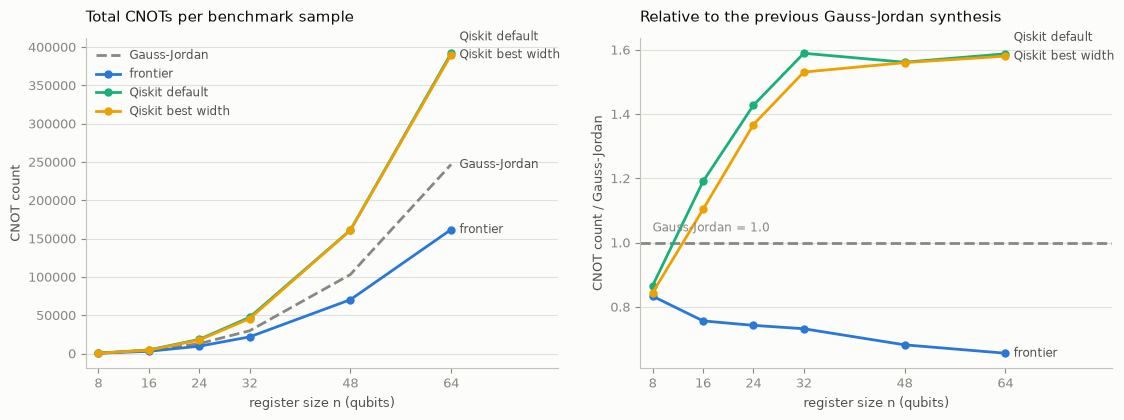

In [11]:
import matplotlib.pyplot as plt

SURFACE, GRID_COLOR, AXIS_COLOR = "#fcfcfb", "#e1e0d9", "#c3c2b7"
INK, INK_SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
SERIES_COLORS = {
    "frontier PMH": "#2a78d6",             # blue
    "Qiskit PMH (default)": "#1baf7a",     # aqua
    "Qiskit PMH (best width)": "#eda100",  # yellow
}
BASELINE = "Gauss-Jordan (previous)"
SHORT_NAMES = {
    "frontier PMH": "frontier",
    "Qiskit PMH (default)": "Qiskit default",
    "Qiskit PMH (best width)": "Qiskit best width",
    BASELINE: "Gauss-Jordan",
}


def style_axes(ax, title, ylabel):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS_COLOR)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_xlabel("register size n (qubits)", color=INK_SECONDARY, fontsize=9)
    ax.set_ylabel(ylabel, color=INK_SECONDARY, fontsize=9)
    ax.set_xticks(degrees)
    ax.set_xlim(degrees[0] - 2, degrees[-1] + 17)  # room for end-of-line labels


def label_line_ends(ax, end_values):
    """Direct labels at each line's last point, nudged apart if they collide."""
    span = ax.get_ylim()[1] - ax.get_ylim()[0]
    placed = []
    for name, value in sorted(end_values.items(), key=lambda item: item[1]):
        y = value
        while any(abs(y - other) < 0.05 * span for other in placed):
            y += 0.05 * span
        placed.append(y)
        ax.annotate(SHORT_NAMES[name], (degrees[-1], y), xytext=(6, 0),
                    textcoords="offset points", va="center", annotation_clip=False,
                    color=INK_SECONDARY, fontsize=8.5)


fig, (ax_abs, ax_rel) = plt.subplots(1, 2, figsize=(11.5, 4.3), facecolor=SURFACE)

# Left panel: absolute totals. The previous implementation is context, so it is
# drawn in the de-emphasis gray; the three PMH variants carry the categorical hues.
ax_abs.plot(degrees, totals[BASELINE], color=MUTED, linestyle="--",
            linewidth=2, label=SHORT_NAMES[BASELINE])
for name, color in SERIES_COLORS.items():
    ax_abs.plot(degrees, totals[name], color=color, linewidth=2,
                marker="o", markersize=5, label=SHORT_NAMES[name])
style_axes(ax_abs, "Total CNOTs per benchmark sample", "CNOT count")
label_line_ends(ax_abs, {name: totals[name][-1] for name in totals})
ax_abs.legend(frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY, loc="upper left")

# Right panel: same data indexed to the Gauss-Jordan baseline (= 1.0), which makes
# the 20-40% differences readable without a second y-axis.
ax_rel.axhline(1.0, color=MUTED, linestyle="--", linewidth=2)
ratios = {
    name: [count / base for count, base in zip(totals[name], totals[BASELINE])]
    for name in SERIES_COLORS
}
for name, color in SERIES_COLORS.items():
    ax_rel.plot(degrees, ratios[name], color=color, linewidth=2,
                marker="o", markersize=5, label=SHORT_NAMES[name])
style_axes(ax_rel, "Relative to the previous Gauss-Jordan synthesis",
           "CNOT count / Gauss-Jordan")
label_line_ends(ax_rel, {name: values[-1] for name, values in ratios.items()})
ax_rel.annotate(SHORT_NAMES[BASELINE] + " = 1.0", (degrees[0], 1.0), xytext=(0, 6),
                textcoords="offset points", va="bottom", color=MUTED, fontsize=8.5)

fig.tight_layout()
plt.show()

### Takeaway

- **Correctness**: replaying the emitted CNOT schedule over GF(2) reproduces every
  controlled power `M**(2**k)` exactly, at all degrees checked.
- **vs the previous Gauss–Jordan synthesis**: `_pmh_cnot_schedule` uses ~17% fewer
  CNOTs at n = 8, growing to ~34% fewer at n = 64 (161,867 vs 246,824 per
  benchmark sample) — the O(n²/log n) advantage kicking in.
- **vs Qiskit**: perhaps surprisingly, Qiskit's `synth_cnot_count_full_pmh`
  produces *more* CNOTs than even plain Gauss–Jordan for n ≥ 16 (~1.6× at n = 64),
  and sweeping its section size barely helps. Qiskit's implementation adds a
  greedy "back-reduce the pivot row" heuristic on top of the paper's algorithm;
  on dense matrices like the companion-matrix powers here (about half the entries
  are 1) that heuristic backfires badly. An experimental variant of our
  implementation *with* that heuristic reproduced Qiskit's counts to within 0.1%,
  which is what identified it as the culprit — the final implementation follows
  the paper without it, ending up ~2.4× below Qiskit at n = 64.

So for this benchmark's circuits, the in-package synthesis is strictly better
than both the previous implementation and Qiskit's, while keeping the package
free of a Qiskit dependency.